# A3 — Anatomy of the stability / flexibility subpopulations

*Tutorial for `src/analysis/stats/stability_flexibility_anatomy.py` (plan §3).*

**The question.** A1 labelled each electrode stability-selective (`S`, the LWPC
congruency×proportion interaction) and/or flexibility-selective (`F`, the LWPS
switch×proportion interaction). A2 asked whether the *same electrodes* carry
both. A3 asks the next, descriptive question: **are the distinct subpopulations
in different PLACES in the brain?**

**The trap this whole analysis is built around: coverage bias.** iEEG electrode
placement is decided by clinicians for surgical reasons, *not* uniformly. So if
"flexibility" electrodes look more parietal than "stability" electrodes, that
could just mean the patients happened to be wired more in parietal cortex. **Every
anatomical claim here must be conditioned on where the electrodes actually are.**

This notebook walks through the four pieces of the module:
1. `build_electrode_roi_map` / `attach_roi` — put each electrode in an ROI and a
   selectivity group (`both` / `S_only` / `F_only` / `neither`).
2. `build_coverage_matrix` — the subject × ROI coverage we condition on.
3. `roi_group_enrichment_test` — the coverage-conditioned association test.
4. the brain-surface figure (a thin wrapper over the existing vis renderer).

We use the module's ground-truth synthetic generator so it runs with **no data on
disk** — and, crucially, so we can check the test on data where we *know* the
answer (a planted association, and a null).

In [1]:
import os, sys
# make the project importable no matter where the notebook is launched from
here = os.getcwd()
root = here
for _ in range(6):
    if os.path.exists(os.path.join(root, 'src', 'analysis')):
        break
    root = os.path.dirname(root)
if root not in sys.path:
    sys.path.insert(0, root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.stats import stability_flexibility_anatomy as sfa
print("loaded stability_flexibility_anatomy from", sfa.__file__)

loaded stability_flexibility_anatomy from /home/user/GlobalLocal/src/analysis/stats/stability_flexibility_anatomy.py


## 1. Labels + electrode→ROI map

On real data you'd get `labels` from A1 (`per_electrode_anova_labels`) and the
electrode→ROI mapping from the shared atlas:

```python
from src.analysis.utils.general_utils import make_or_load_subjects_electrodes_to_ROIs_dict
from src.analysis.config.rois import rois_dict
roi_dict = make_or_load_subjects_electrodes_to_ROIs_dict(subjects, task, LAB_root, save_dir)
e2r      = sfa.build_electrode_roi_map(roi_dict, rois_dict)   # {electrode: ROI group}
```

`build_electrode_roi_map` flattens the nested `{subject: {channel: Destrieux
label}}` atlas into a flat `{electrode: ROI group}` using the coarse groups in
`config/rois.py` (dlpfc, lpfc, acc, parietal, occ, v1). ROI groups can share
anatomical labels, so the **first** group listed wins (deterministic).

Here we synthesize both, with a *planted* association: `both`/`S_only` electrodes
biased frontal, `F_only` biased posterior (strength `enrichment=0.6`).

In [2]:
labels, e2r = sfa._synthetic_anatomy(enrichment=0.6, seed=1)
print("labels:", labels.shape, "| electrode->ROI entries:", len(e2r))
labels.head()

labels: (397, 4) | electrode->ROI entries: 397


,subject,electrode,S,F
0,S00,S00-e0,0,0
1,S00,S00-e1,0,0
2,S00,S00-e2,0,0
3,S00,S00-e3,0,1
4,S00,S00-e4,0,0


`attach_roi` joins the labels to their ROI and derives the 4-way `group`
from `(S, F)`.

In [3]:
lab_roi = sfa.attach_roi(labels, e2r)
print("group counts:")
print(lab_roi['group'].value_counts())
lab_roi.head()

group counts:
group
neither    271
F_only      59
S_only      47
both        20
Name: count, dtype: int64


,subject,electrode,S,F,roi,group
0,S00,S00-e0,0,0,lpfc,neither
1,S00,S00-e1,0,0,parietal,neither
2,S00,S00-e2,0,0,parietal,neither
3,S00,S00-e3,0,1,dlpfc,F_only
4,S00,S00-e4,0,0,parietal,neither


## 2. Coverage — the thing we condition on

`build_coverage_matrix` asks, for every subject × ROI, *does this subject have
**any** electrode in this ROI?* This is about where the grid is, not where the
effects are — so it uses **all** electrodes, selective or not.

In [4]:
coverage = sfa.build_coverage_matrix(lab_roi)
print("coverage matrix:", coverage.shape, "(subjects x ROIs)")
print("\nsubjects covering each ROI:")
print(coverage.sum(axis=0).sort_values(ascending=False))
coverage.astype(int)

coverage matrix: (12, 6) (subjects x ROIs)

subjects covering each ROI:
roi
dlpfc       11
occ         10
acc          9
lpfc         9
v1           8
parietal     7
dtype: int64


roi,acc,dlpfc,lpfc,occ,parietal,v1
subject,,,,,,
S00,0,1,1,1,1,0
S01,1,1,1,1,1,1
S02,1,0,1,1,1,1
S03,1,1,1,1,0,1
S04,1,1,0,1,0,0
S05,1,1,1,1,0,0
S06,1,1,1,1,1,1
S07,1,1,1,1,0,1
S08,1,1,0,0,1,1


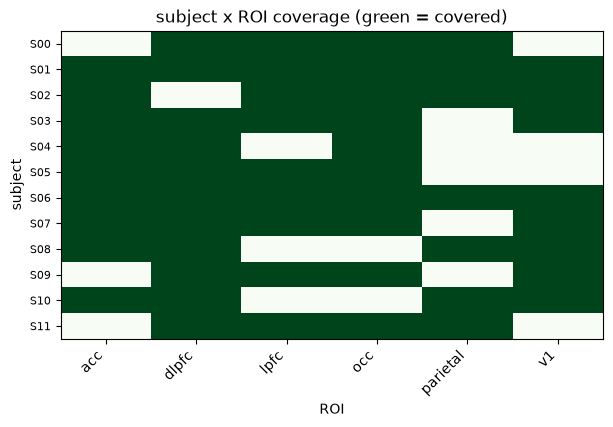

In [5]:
# visualise coverage: green = subject has an electrode in that ROI
fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(coverage.astype(int).to_numpy(), aspect='auto', cmap='Greens', vmin=0, vmax=1)
ax.set_xticks(range(coverage.shape[1])); ax.set_xticklabels(coverage.columns, rotation=45, ha='right')
ax.set_yticks(range(coverage.shape[0])); ax.set_yticklabels(coverage.index, fontsize=8)
ax.set(title="subject x ROI coverage (green = covered)", xlabel="ROI", ylabel="subject")
plt.show()

## 3. ROI histograms per group (descriptive)

Before any test, look at the raw picture: how many electrodes of each group fall
in each ROI. `roi_group_histogram` returns the tidy table; we plot it, annotating
each ROI with **how many subjects cover it** so counts are read against coverage.

roi     acc  dlpfc  lpfc  occ  parietal  v1
group                                      
both      5      3     8    1         0   3
S_only   11     18     9    5         2   2
F_only    3      6     3   20        12  15


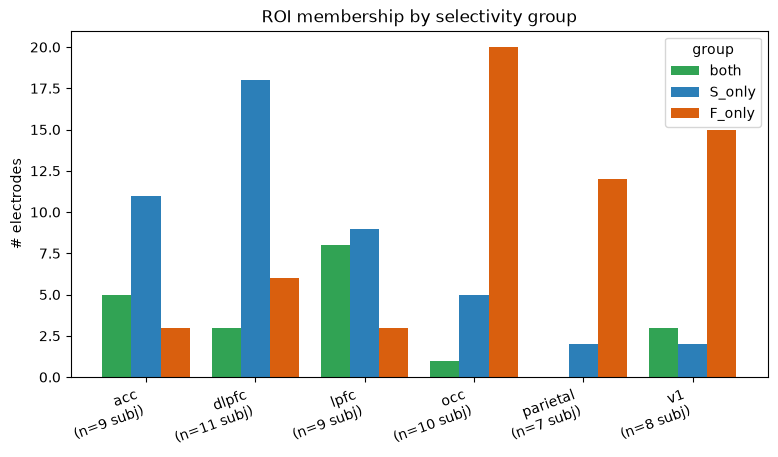

In [6]:
hist = sfa.roi_group_histogram(lab_roi)
print(hist)

rois = list(hist.columns); groups = list(hist.index)
x = np.arange(len(rois)); w = 0.8/len(groups)
cov = coverage.sum(axis=0)
fig, ax = plt.subplots(figsize=(9, 4.5))
for k, g in enumerate(groups):
    ax.bar(x + k*w, hist.loc[g].to_numpy(), w, label=g, color=sfa.GROUP_COLORS.get(g))
ax.set_xticks(x + w*(len(groups)-1)/2)
ax.set_xticklabels([f"{r}\n(n={int(cov.get(r,0))} subj)" for r in rois], rotation=20, ha='right')
ax.set(ylabel="# electrodes", title="ROI membership by selectivity group")
ax.legend(title="group"); plt.show()

You can *see* the planted structure — `S_only`/`both` lean frontal (dlpfc,
lpfc, acc), `F_only` leans posterior (occ, parietal, v1). But eyeballing isn't a
test, and the counts are entangled with coverage. That's what step 4 fixes.

## 4. The coverage-conditioned enrichment test

`roi_group_enrichment_test` asks: **is selectivity-group membership associated
with ROI, beyond what coverage forces?**

- It keeps only ROIs sampled in ≥ `min_subjects` subjects (the coverage filter).
- Statistic: a Pearson **χ²** on the group × ROI contingency table.
- **Null:** permute the `group` label **within each subject** (`n_perm` times) and
  recompute χ². Shuffling *within subject* holds each subject's group counts and
  each electrode's ROI fixed, so the null respects the subject nesting **and**
  the coverage simultaneously — the difference is tested against exactly the
  placement the patients actually had. `p = (#{null ≥ observed} + 1)/(n_perm+1)`.

In [7]:
res = sfa.roi_group_enrichment_test(lab_roi, coverage, min_subjects=3, n_perm=5000, seed=0)
print("ROIs tested (>= 3 subjects):", res['rois_tested'])
print(f"observed chi2 = {res['observed_stat']:.2f}")
print(f"permutation p = {res['p']:.4f}")
print(f"electrodes entering the test: {res['n_electrodes']}")
print("\nper-ROI coverage (subjects):", dict(res['per_roi_coverage']))
print("\ngroup x ROI contingency (restricted to covered ROIs):")
res['contingency']

ROIs tested (>= 3 subjects): ['acc', 'dlpfc', 'lpfc', 'occ', 'parietal', 'v1']
observed chi2 = 55.27
permutation p = 0.0002
electrodes entering the test: 126

per-ROI coverage (subjects): {'acc': np.int64(9), 'dlpfc': np.int64(11), 'lpfc': np.int64(9), 'occ': np.int64(10), 'parietal': np.int64(7), 'v1': np.int64(8)}

group x ROI contingency (restricted to covered ROIs):


,acc,dlpfc,lpfc,occ,parietal,v1
both,5,3,8,1,0,3
S_only,11,18,9,5,2,2
F_only,3,6,3,20,12,15


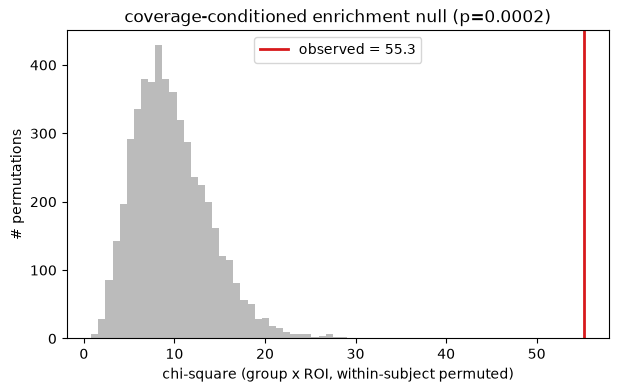

In [8]:
# the within-subject permutation null vs the observed statistic
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(res['null'], bins=40, color="#bbb")
ax.axvline(res['observed_stat'], color="#d7191c", lw=2, label=f"observed = {res['observed_stat']:.1f}")
ax.legend(); ax.set(title=f"coverage-conditioned enrichment null (p={res['p']:.4f})",
                    xlabel="chi-square (group x ROI, within-subject permuted)", ylabel="# permutations")
plt.show()

The observed χ² sits far in the tail of the within-subject null → the
group×ROI association is real, *not* an artifact of where the electrodes are.

### The essential control: does the test manufacture significance?

Re-run on data generated with **no** planted association (`enrichment=0.0`). A
trustworthy test must come back non-significant here — otherwise every result it
gives is suspect.

In [9]:
labels0, e2r0 = sfa._synthetic_anatomy(enrichment=0.0, seed=1)
lab0 = sfa.attach_roi(labels0, e2r0)
cov0 = sfa.build_coverage_matrix(lab0)
res0 = sfa.roi_group_enrichment_test(lab0, cov0, min_subjects=3, n_perm=5000, seed=0)
print(f"NULL data:    chi2 = {res0['observed_stat']:.2f}   p = {res0['p']:.4f}   -> "
      f"{'significant' if res0['p']<0.05 else 'n.s. (correct!)'}")
print(f"PLANTED data: chi2 = {res['observed_stat']:.2f}   p = {res['p']:.4f}   -> "
      f"{'significant (correct!)' if res['p']<0.05 else 'n.s.'}")

NULL data:    chi2 = 14.69   p = 0.2246   -> n.s. (correct!)
PLANTED data: chi2 = 55.27   p = 0.0002   -> significant (correct!)


✓ Null → n.s., planted → significant. The within-subject permutation is
doing its job.

### Coverage filter sensitivity (`min_subjects`)

The `min_subjects` cutoff is the coverage condition made concrete. Raising it
drops thinly-sampled ROIs (which can't support a population claim) and shrinks the
test; report the verdict as a function of it, not one snapshot.

In [10]:
for k in (2, 3, 4, 5):
    r = sfa.roi_group_enrichment_test(lab_roi, coverage, min_subjects=k, n_perm=3000, seed=0)
    print(f"min_subjects={k}: ROIs tested={len(r['rois_tested'])}  "
          f"n_elec={r['n_electrodes']:4d}  chi2={r['observed_stat']:6.2f}  p={r['p']:.4f}")

min_subjects=2: ROIs tested=6  n_elec= 126  chi2= 55.27  p=0.0003


min_subjects=3: ROIs tested=6  n_elec= 126  chi2= 55.27  p=0.0003


min_subjects=4: ROIs tested=6  n_elec= 126  chi2= 55.27  p=0.0003


min_subjects=5: ROIs tested=6  n_elec= 126  chi2= 55.27  p=0.0003


## 5. The brain-surface figure

`plot_selectivity_groups_on_brain` builds the per-group electrode lists and hands
them to the existing Glasser SVG renderer in `src/analysis/vis/` as colour-coded
highlight sets — it does **not** write new surface code. That renderer needs
MNE + PyVista + an fsaverage/Glasser template, which only live on the cluster; off
the cluster the wrapper **falls back** to the ROI-histogram figure so a job never
crashes for want of the surface stack. (Here it will fall back.)

In [11]:
out = sfa.plot_selectivity_groups_on_brain(lab_roi, "/tmp/a3_brain.svg", coverage=coverage)
print("wrote:", out)
print("(on the cluster, with MNE+PyVista, this renders the Glasser cortical surface"
      " with both/S_only/F_only electrodes colour-coded.)")

[A3] brain-surface render unavailable (ModuleNotFoundError: No module named 'pyvista'); falling back to ROI histogram.


wrote: /tmp/a3_brain_roi_hist.png
(on the cluster, with MNE+PyVista, this renders the Glasser cortical surface with both/S_only/F_only electrodes colour-coded.)


## Running it on real data

The productionised job lives in `dcc_scripts/stats/`:

```bash
cd dcc_scripts/stats
# validate the whole path in seconds (planted enrichment):
DATA_SOURCE=synthetic bash submit_stability_flexibility_anatomy_dcc.sh
# the null version:
DATA_SOURCE=synthetic SYNTHETIC_ENRICHMENT=0.0 bash submit_stability_flexibility_anatomy_dcc.sh
# real run — set EPOCHS_ROOT_FILE in the submit script, then:
bash submit_stability_flexibility_anatomy_dcc.sh
```

It assembles the same long-format HG table as the A1/A2 job, runs A1 to get the
`S`/`F` flags, maps electrodes to ROIs via the atlas, and writes
`anatomy_labels_roi.csv`, `coverage_matrix.csv`, `group_roi_contingency.csv`,
`roi_enrichment.json`, the figures, and `summary.txt`.

### Acceptance criteria (plan §3), and where they're met
- **Every claim conditioned on coverage** → `min_subjects` filter + per-ROI
  coverage reported alongside every result.
- **Null-respecting inference** → within-subject permutation of the group label.
- **The test doesn't manufacture significance** → verified on the `enrichment=0`
  synthetic above.
- **The brain figure distinguishes the groups** → colour-coded highlight sets
  (with a documented fallback).